# Notebook 2 - Scarcity Regimes and System Tightness

## Objective

This notebook investigates the physical and operational conditions associated with extreme electricity prices in Alberta.

Notebook 1 established how Alberta’s electricity market changed and how its principal variables behave. This notebook narrows the analysis to periods of system stress. It evaluates whether scarcity is associated with: limited reported capacity margin; reduced available supply margin; reduced thermal headroom; elevated generation outages; dependence on intertie imports; and combinations of these operating conditions.

The analysis distinguishes structural capacity from operational availability. Installed capacity measures the reported size of the generation fleet, whereas available capacity measures the supply reported as available during a particular hour. Neither measure is equivalent to operating reserve. The margin variables developed here should therefore be interpreted as system-tightness proxies rather than official reserve measures.

Price thresholds are used to identify the market outcomes associated with scarcity. These thresholds do not define physical scarcity by themselves. Instead, the notebook examines which physical conditions tend to accompany progressively more extreme price outcomes.

The analysis is descriptive and contemporaneous. It does not establish causal effects or out-of-sample forecasting performance.

## 1. Environment, Data, and Analytical Definitions

### 1.1 Imports and canonical dataset

The notebook uses the canonical hourly master dataset produced by the project pipeline. The master DataFrame remains authoritative. Notebook-specific variables are stored separately in scarcity_features.

The study period covers Alberta operating years 2015–2025.

In [ ]:
# ---------------------------------------------------------------------
# Configure project imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path: 
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f"Canonical master loaded: "
    f"{master.shape[0]:,} rows × {master.shape[1]:,} columns"
)

Canonical master loaded: 96,425 rows × 494 columns


### 1.2 Study period and input validation

The main analysis covers Alberta operting years 2015-2025. Timestamp integrity, annual coverage, required columns, and missingness in the principal Notebook 2 variables are checked before any scarcity features are constructed.

Missing intertie observations are retained as missing rather than interpreted as zero imports. Technology-level availability field are also treated cautiously because AESO technology classifications and reporting boundaries changed during the study period. 

In [14]:
# ---------------------------------------------------------------------
# Define the study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025
ALBERTA_TIMEZONE = "America/Edmonton"

PRICE_THRESHOLDS = [100, 300, 500, 900]
PRIMARY_SCARCITY_THRESHOLD = 500

THERMAL_TECHNOLOGIES = [
    "coal",
    "cogeneration",
    "combined_cycle",
    "dual_fuel",
    "gas_fired_steam",
    "simple_cycle",
]

THERMAL_AVAILABILITY_COLUMNS = [
    f"{technology}_system_available"
    for technology in THERMAL_TECHNOLOGIES
]

THERMAL_GENERATION_COLUMNS = [
    f"{technology}_system_generation"
    for technology in THERMAL_TECHNOLOGIES
]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "year_alberta",
    "pool_price",
    "ail_mw",
    "total_system_capacity",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "thermal_outage_mw",
    "renewable_outage_mw",
    "simple_cycle_outage",
    "combined_cycle_outage",
    "cogeneration_outage",
    "total_imports_mw",
    "total_exports_mw",
    "net_imports_mw",
    "wind_system_generation",
    "solar_system_generation",
    "atc_sk_import",
    "atc_wecc_import",
    "ttc_sk_import",
    "ttc_wecc_import",
] + THERMAL_AVAILABILITY_COLUMNS + THERMAL_GENERATION_COLUMNS

missing_required_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_required_columns:
    raise ValueError(
        "Master dataset is missing Notebook 2 columns: "
        f"{missing_required_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(
    master["timestamp_utc"],
    utc=True,
)

master = (
    master
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

master = (
    master.loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    f"Selected period: "
    f"{master['timestamp_alberta'].min()} to "
    f"{master['timestamp_alberta'].max()}"
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 16:00:00-07:00


In [15]:
# ---------------------------------------------------------------------
# Audit annual coverage and decision-relevant missingness
# ---------------------------------------------------------------------

study_years = pd.Index(
    range(STUDY_START_YEAR, STUDY_END_YEAR + 1),
    name="year_alberta",
)

observed_hours = (
    master
    .groupby("year_alberta")
    .size()
    .reindex(study_years, fill_value=0)
)

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start=f"{year}-01-01",
                end=f"{year + 1}-01-01",
                inclusive="left",
                freq="h",
                tz=ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name="expected_hours",
)

expected_hours.index.name = "year_alberta"

annual_coverage = pd.concat(
    [
        expected_hours,
        observed_hours.rename("observed_hours"),
    ],
    axis=1,
)

annual_coverage["unobserved_hours"] = (
    annual_coverage["expected_hours"]
    - annual_coverage["observed_hours"]
)

annual_coverage["coverage_pct"] = (
    annual_coverage["observed_hours"]
    / annual_coverage["expected_hours"]
    * 100
)

AUDIT_COLUMNS = [
    "pool_price",
    "ail_mw",
    "total_system_capacity",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "thermal_outage_mw",
    "net_imports_mw",
    "wind_system_generation",
    "solar_system_generation",
    "atc_sk_import",
    "atc_wecc_import",
]

input_missingness = pd.DataFrame(
    {
        "missing_hours":
            master[AUDIT_COLUMNS].isna().sum(),

        "missing_pct":
            master[AUDIT_COLUMNS].isna().mean() * 100,

        "first_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].min()
            for column in AUDIT_COLUMNS
        ],

        "last_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].max()
            for column in AUDIT_COLUMNS
        ],
    },
    index=AUDIT_COLUMNS,
)

print("Annual study-period coverage")
display(annual_coverage.round({"coverage_pct": 3}))

print("Missingness and reporting windows")
display(input_missingness.round({"missing_pct": 3}))

Annual study-period coverage


,expected_hours,observed_hours,unobserved_hours,coverage_pct
year_alberta,,,,
2015,8760,8760,0,100.00
2016,8784,8784,0,100.00
2017,8760,8760,0,100.00
2018,8760,8760,0,100.00
2019,8760,8760,0,100.00
2020,8784,8784,0,100.00
2021,8760,8760,0,100.00
2022,8760,8760,0,100.00
2023,8760,8760,0,100.00


Missingness and reporting windows


,missing_hours,missing_pct,first_reported,last_reported
pool_price,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
ail_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_capacity,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_available,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_generation,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_outage_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
thermal_outage_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
net_imports_mw,3666,3.802,2015-01-01 00:00:00-07:00,2025-07-31 23:00:00-06:00
wind_system_generation,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
solar_system_generation,25656,26.607,2017-12-05 00:00:00-07:00,2025-12-31 16:00:00-07:00


### 1.3 Structural market regimes

Alberta’s generation fleet changed substantially during the study period. Relationships estimated over the full sample may therefore conceal important differences between earlier and later operating environments.

The following externally defined calendar regimes are used:

- **2015–2017:** coal-dominant system;
- **2018–2021:** coal-to-gas transition;
- **2022–2024:** late coal exit and renewable buildout; and
- **2025:** coal-free gas-renewable system.

These regimes are based on the generation transition documented in Notebook 1. They are not defined using the price outcome examined in this notebook.

In [16]:
# ---------------------------------------------------------------------
# Define structural generation regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    'Coal-dominant',
    'Coal-to-gas transition',
    'Late coal exit and renewable buildout',
    'Coal-free gas-renewable system',
]

structural_regime = pd.Categorical(
    np.select(
        [
            master['year_alberta'].le(2017),
            master['year_alberta'].le(2021),
            master['year_alberta'].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default = STRUCTURAL_REGIME_ORDER[3],
    ),
    categories = STRUCTURAL_REGIME_ORDER,
    ordered = True,
)

structural_regime_summary = (
    pd.DataFrame({
        'structural_regime': structural_regime,
        'year_alberta': master['year_alberta'],
        'pool_price': master['pool_price'],
    })
    .groupby('structural_regime', observed = True)
    .agg(
        start_year = ('year_alberta', 'min'),
        end_year = ('year_alberta', 'max'),
        observations = ('year_alberta', 'size'),
        average_price = ('pool_price', 'mean'),
    )
)

display(structural_regime_summary.round(2))

,start_year,end_year,observations,average_price
structural_regime,,,,
Coal-dominant,2015,2017,26304,24.59
Coal-to-gas transition,2018,2021,35064,63.46
Late coal exit and renewable buildout,2022,2024,26304,119.57
Coal-free gas-renewable system,2025,2025,8753,43.69


### 1.4 Analytical Variables

The notebook separates several related concepts:

- **Net load:** Alberta Internal Load minus wind and solar generation.
- **Reported capacity margin:** reported system capacity minus load.
- **Domestic available margin:** reported available system supply minus load.
- **Intertie-supported margin:** domestic available margin plus observed net imports.
- **Reported supply headroom:** available system supply minus actual system generation.
- **Thermal headroom:** reported thermal availability minus actual thermal generation.
- **Outage burden:** unavailable generation in MW and relative to reported capacity.
- **Import capability:** reported Saskatchewan and WECC import available-transfer capability.

These are analytical proxies. In particular, domestic available margin and reported supply headroom should not be described as official AESO operating reserve or supply cushion.

In [17]:
# ---------------------------------------------------------------------
# Construct Notebook 2 variables without modifying master
# ---------------------------------------------------------------------

scarcity_features = pd.DataFrame(index=master.index)

for threshold in PRICE_THRESHOLDS:
    scarcity_features[
        f"price_at_or_above_{threshold}"
    ] = master["pool_price"].ge(threshold)

scarcity_features["price_regime"] = pd.cut(
    master["pool_price"],
    bins=[
        -np.inf,
        100,
        300,
        500,
        900,
        np.inf,
    ],
    labels=[
        "Below $100",
        "$100–$299",
        "$300–$499",
        "$500–$899",
        "$900+",
    ],
    right=False,
)

scarcity_features["variable_renewable_generation_mw"] = (
    master["wind_system_generation"]
    + master["solar_system_generation"].fillna(0)
)

scarcity_features["net_load_mw"] = (
    master["ail_mw"]
    - scarcity_features[
        "variable_renewable_generation_mw"
    ]
)

scarcity_features["reported_thermal_available_mw"] = (
    master[THERMAL_AVAILABILITY_COLUMNS]
    .sum(axis=1, min_count=1)
)

scarcity_features["reported_thermal_generation_mw"] = (
    master[THERMAL_GENERATION_COLUMNS]
    .sum(axis=1, min_count=1)
)

scarcity_features["thermal_headroom_mw"] = (
    scarcity_features["reported_thermal_available_mw"]
    - scarcity_features["reported_thermal_generation_mw"]
)

scarcity_features["thermal_utilization_pct"] = (
    scarcity_features["reported_thermal_generation_mw"]
    / scarcity_features[
        "reported_thermal_available_mw"
    ].replace(0, np.nan)
    * 100
)

scarcity_features["reported_capacity_margin_mw"] = (
    master["total_system_capacity"]
    - master["ail_mw"]
)

scarcity_features["domestic_available_margin_mw"] = (
    master["total_system_available"]
    - master["ail_mw"]
)

scarcity_features["intertie_supported_margin_mw"] = (
    scarcity_features["domestic_available_margin_mw"]
    + master["net_imports_mw"]
)

scarcity_features["reported_supply_headroom_mw"] = (
    master["total_system_available"]
    - master["total_system_generation"]
)

scarcity_features["available_margin_pct_of_load"] = (
    scarcity_features["domestic_available_margin_mw"]
    / master["ail_mw"].replace(0, np.nan)
    * 100
)

scarcity_features["outage_share_of_capacity_pct"] = (
    master["total_outage_mw"]
    / master["total_system_capacity"].replace(0, np.nan)
    * 100
)

scarcity_features["import_atc_mw"] = (
    master["atc_sk_import"]
    + master["atc_wecc_import"]
)

scarcity_features["import_ttc_mw"] = (
    master["ttc_sk_import"]
    + master["ttc_wecc_import"]
)

scarcity_features["net_import_share_of_load_pct"] = (
    master["net_imports_mw"]
    / master["ail_mw"].replace(0, np.nan)
    * 100
)

In [19]:
# ---------------------------------------------------------------------
# Helper functions for percentiles, deciles, and comparisons
# ---------------------------------------------------------------------

def within_year_percentile(values):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
    })

    return (
        frame
        .groupby("year_alberta")["value"]
        .rank(method="average", pct=True)
    )

def percentile_to_decile(percentile):
    return (
        np.floor(percentile * 10)
        .clip(upper=9)
        .astype("Int64")
    )

def compare_event_means(series_by_label, event):
    values = pd.DataFrame(series_by_label)

    result = pd.DataFrame({
        "normal_mean": values.loc[~event].mean(),
        "scarcity_mean": values.loc[event].mean(),
        "normal_median": values.loc[~event].median(),
        "scarcity_median": values.loc[event].median(),
    })

    result["mean_difference"] = (
        result["scarcity_mean"]
        - result["normal_mean"]
    )

    result["mean_pct_difference"] = (
        result["mean_difference"]
        / result["normal_mean"].replace(0, np.nan)
        * 100
    )

    return result

PERCENTILE_FEATURES = {
    "load": master["ail_mw"],
    "net_load": scarcity_features["net_load_mw"],
    "available_margin": scarcity_features["domestic_available_margin_mw"],
    "thermal_headroom": scarcity_features["thermal_headroom_mw"],
    "total_outage": master["total_outage_mw"],
    "net_imports": master["net_imports_mw"],
    "import_capability": scarcity_features["import_atc_mw"],
}

for feature_name, values in PERCENTILE_FEATURES.items():
    percentile_column = (
        f"{feature_name}_percentile_within_year"
    )
    decile_column = f"{feature_name}_decile"

    scarcity_features[percentile_column] = (
        within_year_percentile(values)
    )

    scarcity_features[decile_column] = (
        percentile_to_decile(
            scarcity_features[percentile_column]
        )
    )

In [20]:
# ---------------------------------------------------------------------
# Define interpretable operating states
# ---------------------------------------------------------------------

MARGIN_STATE_ORDER = [
    'Critical', 
    'Tight', 
    'Balanced',
    'Loose',
]

margin_percentile = scarcity_features[
    'available_margin_percentile_within_year'
]

scarcity_features['margin_state'] = pd.Categorical(
    np.select(
        [
            margin_percentile.le(0.05),
            margin_percentile.le(0.20),
            margin_percentile.le(0.80),
        ],
        [
            'Critical',
            'Tight',
            'Balanced',
        ],
        default = 'Loose',
    ),
    categories = MARGIN_STATE_ORDER,
    ordered = True,
)

scarcity_features['outage_state'] = np.where(
    scarcity_features[
        'total_outage_percentile_within_year'
    ].ge(0.80),
    'High outage', 
    'Lower outage',
)

CAPABILITY_STATE_ORDER = [
    'Constrainted',
    'Typical',
    'High capability',
]

capability_percentile = scarcity_features[
    'import_capability_percentile_within_year'
]

scarcity_features['capability_state'] = pd.Categorical(
    np.select(
        [
            capability_percentile.le(0.20),
            capability_percentile.le(0.80),
        ],
        [
            'Constrainted',
            'High capability',
        ],
        default = 'Typical',
    ),
    categories = CAPABILITY_STATE_ORDER,
    ordered = True,
)

FLOW_STATE_ORDER = [
    'Net exporting',
    'Balanced',
    'Net importing',
    'Not reported',
]

scarcity_features['intertie_flow_state'] = np.select(
    [
        master['net_imports_mw'].isna(),
        master['net_imports_mw'].lt(0),
        master['net_imports_mw'].gt(0),
    ],
    [
        'Not reported',
        'Net exporting',
        'Net importing',
    ], 
    default = 'Balanced',
)

display(scarcity_features.head())

,price_at_or_above_100,price_at_or_above_300,price_at_or_above_500,price_at_or_above_900,price_regime,variable_renewable_generation_mw,net_load_mw,reported_thermal_available_mw,reported_thermal_generation_mw,thermal_headroom_mw,thermal_utilization_pct,reported_capacity_margin_mw,domestic_available_margin_mw,intertie_supported_margin_mw,reported_supply_headroom_mw,available_margin_pct_of_load,outage_share_of_capacity_pct,import_atc_mw,import_ttc_mw,net_import_share_of_load_pct,load_percentile_within_year,load_decile,net_load_percentile_within_year,net_load_decile,available_margin_percentile_within_year,available_margin_decile,thermal_headroom_percentile_within_year,thermal_headroom_decile,total_outage_percentile_within_year,total_outage_decile,net_imports_percentile_within_year,net_imports_decile,import_capability_percentile_within_year,import_capability_decile,margin_state,outage_state,capability_state,intertie_flow_state
0,False,False,False,False,Below $100,862.961868,8347.038132,9941.0,6582.944677,3358.055323,66.220146,6324.5,1624.0,889.0,3183.562894,17.633008,21.161286,765.0,830.0,-7.980456,0.522374,5,0.353995,3,0.196176,1,0.415183,4,0.435788,4,0.002055,0,0.277055,2,Tight,Lower outage,High capability,Net exporting
1,False,False,False,False,Below $100,926.189480,8118.810520,9827.0,6413.605041,3413.394959,65.265137,6489.5,1677.0,942.0,3196.657922,18.540630,21.882262,765.0,830.0,-8.126036,0.441438,4,0.268265,2,0.205137,2,0.446689,4,0.509646,5,0.002055,0,0.277055,2,Balanced,Lower outage,High capability,Net exporting
2,False,False,False,False,Below $100,823.660797,8015.339203,10172.0,5989.258194,4182.741806,58.879849,6695.5,2228.0,1878.0,4090.841863,25.206471,19.661399,765.0,830.0,-3.959724,0.343379,3,0.231849,2,0.331393,3,0.843493,8,0.304110,3,0.056164,0,0.277055,2,Balanced,Lower outage,High capability,Net exporting
3,False,False,False,False,Below $100,764.893106,7977.106894,10142.0,5822.894685,4319.105315,57.413673,6792.5,2295.0,2045.0,4281.283895,26.252574,19.854517,765.0,830.0,-2.859757,0.302169,3,0.219635,2,0.351712,3,0.885046,8,0.318322,3,0.092123,0,0.277055,2,Balanced,Lower outage,High capability,Net exporting
4,False,False,False,False,Below $100,824.108485,7874.891515,9939.0,5719.917422,4219.082578,57.550231,6835.5,2135.0,1885.0,4119.859996,24.543051,21.161286,765.0,830.0,-2.873894,0.283733,2,0.186301,1,0.308619,3,0.854795,8,0.435788,4,0.092123,0,0.277055,2,Balanced,Lower outage,High capability,Net exporting


## 2. Scarcity Outcomes and Annual Base Rates

### 2.1 Price-Based Scarcity Definitions

Scarcity is evaluated at several thresholds:

- \$100/MWh identifies broadly elevated prices; 
- \$300/MWh identifies high-price conditions; 
- \$500/MWh is the notebook's primary scarcity thresholds; and
- \$900/MWh identifies the most extreme price outcomes. 

The \$500/MWh threshold is used for most conditional analyses because it isolates severe events while retaining enough observations for meaningful comparisons. 

These thresholds define market outcomes, not physical shortages. 

In [24]:
# ---------------------------------------------------------------------
# Summarize scarcity outcomes across thresholds
# ---------------------------------------------------------------------

event_summary = pd.DataFrame({
    'theshold': PRICE_THRESHOLDS,

    'hours': [
        scarcity_features[
            f'price_at_or_above_{threshold}'
        ].sum()
        for threshold in PRICE_THRESHOLDS
    ],

    'share_of_hours_pct': [
        scarcity_features[
            f'price_at_or_above_{threshold}'
        ].mean() * 100
        for threshold in PRICE_THRESHOLDS
    ],
})

event_summary['definition'] = [
    'Elevated price',
    'High price',
    'Primary scarcity event',
    'Extreme scarcity event',
]

display(event_summary.round(3))

,theshold,hours,share_of_hours_pct,definition
0,100,10057,10.430,Elevated price
1,300,4047,4.197,High price
2,500,2430,2.520,Primary scarcity event
3,900,422,0.438,Extreme scarcity event


### 2.2 Annual Event Base Rates

Scarcity frequency changes materially across years. Every decile, interaction, and stability analysis must therefore be interpreted relative to the base event rate in the corresponding year or structural regime. 

This prevents a year with genreally frequent scarcity from dominating a pooled relationship. 

In [25]:
# ---------------------------------------------------------------------
# Calculate annual event counts and base rates
# ---------------------------------------------------------------------

annual_events = (
    pd.DataFrame({
        'year_alberta': master['year_alberta'],
        'pool_price': master['pool_price'],
        'event_300': scarcity_features['price_at_or_above_300'],
        'event_500': scarcity_features['price_at_or_above_500'],
        'event_900': scarcity_features['price_at_or_above_900'],
    })
    .groupby('year_alberta')
    .agg(
        observed_hours=("pool_price", "size"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
        hours_at_or_above_300=("event_300", "sum"),
        hours_at_or_above_500=("event_500", "sum"),
        hours_at_or_above_900=("event_900", "sum"),
        scarcity_base_rate=("event_500", "mean"),
    )
)

annual_events['scarcity_base_rate_pct'] = (
    annual_events['scarcity_base_rate'] * 100
)

display(annual_events.round(3))

,observed_hours,average_price,median_price,hours_at_or_above_300,hours_at_or_above_500,hours_at_or_above_900,scarcity_base_rate,scarcity_base_rate_pct
year_alberta,,,,,,,,
2015,8760,33.338,20.480,130,95,28,0.011,1.084
2016,8784,18.279,15.460,4,2,0,0.000,0.023
2017,8760,22.186,19.460,11,6,4,0.001,0.068
2018,8760,50.348,33.250,151,102,29,0.012,1.164
2019,8760,54.880,33.510,184,116,17,0.013,1.324
2020,8784,46.716,33.275,149,102,40,0.012,1.161
2021,8760,101.932,57.340,615,310,42,0.035,3.539
2022,8760,162.463,83.780,1194,758,111,0.087,8.653
2023,8760,133.628,57.200,1085,606,52,0.069,6.918


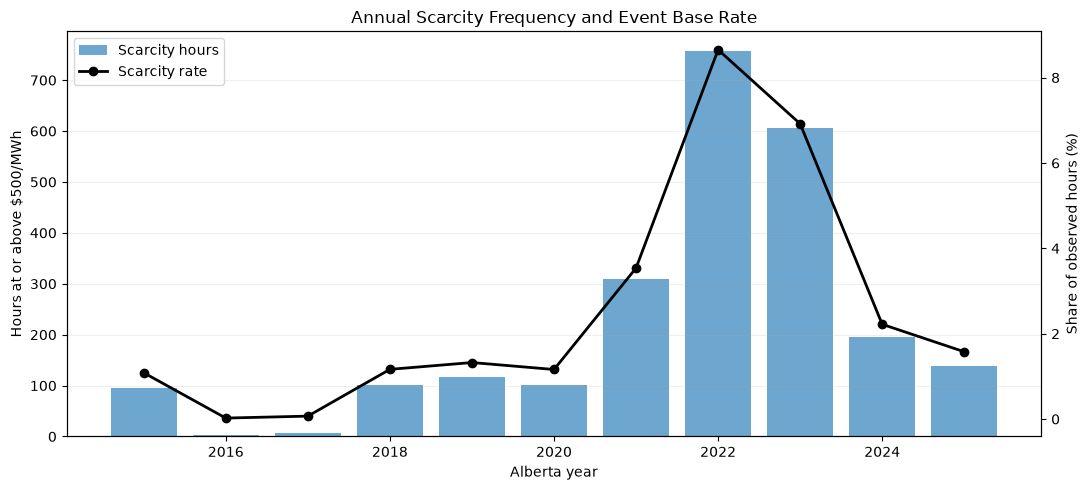

In [26]:
# ---------------------------------------------------------------------
# Plot annual scarcity count and base rate
# ---------------------------------------------------------------------

fig, ax_count = plt.subplots(figsize=(11, 5))

ax_count.bar(
    annual_events.index,
    annual_events["hours_at_or_above_500"],
    alpha=0.65,
    label="Scarcity hours",
)

ax_count.set_xlabel("Alberta year")
ax_count.set_ylabel("Hours at or above $500/MWh")

ax_rate = ax_count.twinx()

ax_rate.plot(
    annual_events.index,
    annual_events["scarcity_base_rate_pct"],
    color="black",
    marker="o",
    linewidth=2,
    label="Scarcity rate",
)

ax_rate.set_ylabel("Share of observed hours (%)")

ax_count.set_title(
    "Annual Scarcity Frequency and Event Base Rate"
)
ax_count.grid(axis="y", alpha=0.20)

lines_1, labels_1 = ax_count.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()

ax_count.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Annual Event Base Rates

Alberta's price environment changed sharply after 2020. Average pool price increased from \$46.72/MWh in 2020 to \$101.93/MWh in 2021, reaching \$162.46/MWh in 2022. Scarcity was most pronounced in 2022, when 758 hours reached at least \$500/MWh - an annual base rate of 8.65% - followed by 606 hours in 2023. 

Conditions moderated substantially in 2024 and 2025, with lower average and median prices and fewer scarcity hours. Nevertheless, extreme-price events remained more frequent than during the usually mild 2016-2017 period, indicating that the post-2023 market normalized without returning completely to those ealrier conditions. 

## 3. Demand Pressure and Net Load

### 3.1 Load and Net-Load Distributions

Gross load measures total Alberta Internal Load. Net load subtracts contemporaneous wind and solar generation and approxmiates the demand that must be met by dispatchable generaiton, hydro, imports and other system resources. 

Notebook 2 uses actual renewable generation only to constructu historical net load. Notebook 4 is responsible for explaining the weather dependence and variability of wind, solar, hydro, and demand. 

In [27]:
# ---------------------------------------------------------------------
# Compare load and net load during scarcity and normal hours
# --------------------------------------------------------------------- 

primary_event = scarcity_features[
    f'price_at_or_above_{PRIMARY_SCARCITY_THRESHOLD}'
]

demand_comparison = compare_event_means(
    {
        'Alberta Internal Load (MW)': master['ail_mw'],
        'Net load (MW)': scarcity_features['net_load_mw'],
        'Variable renewable generation (MW)': scarcity_features['variable_renewable_generation_mw'],
    },
    primary_event,
)

display(demand_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Alberta Internal Load (MW),9655.21,10458.94,9654.00,10506.50,803.74,8.32
Net load (MW),8724.58,9989.69,8741.05,9985.83,1265.11,14.50
Variable renewable generation (MW),930.62,469.25,726.81,355.80,-461.37,-49.58


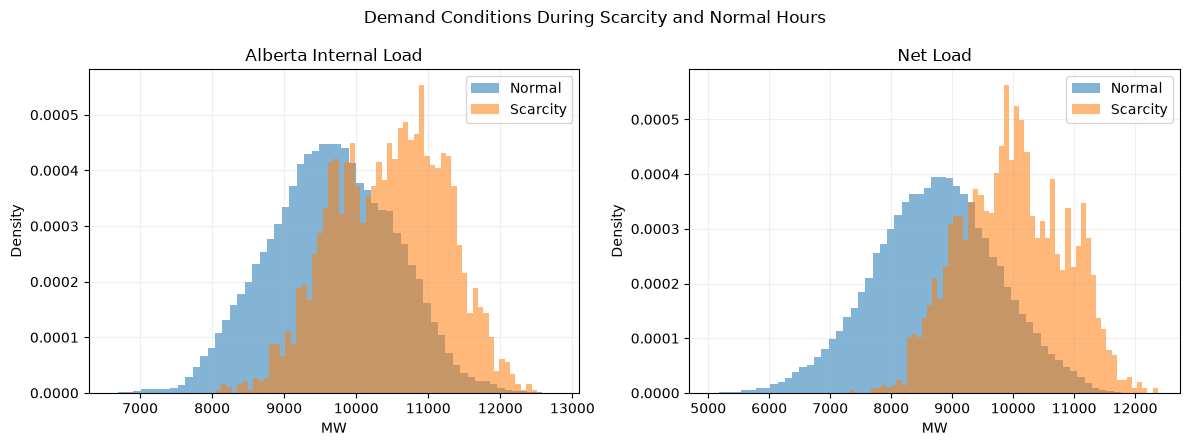

In [29]:
# ---------------------------------------------------------------------
# Plot load and net-load distributions
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1, 
    2, 
    figsize = (12, 4.5),
)

distribution_features = {
    'Alberta Internal Load': master['ail_mw'],
    'Net Load': scarcity_features['net_load_mw'],
}

for axis, (label, values) in zip(
    axes, distribution_features.items(),
):
    axis.hist(
        values.loc[~primary_event].dropna(),
        bins = 60, 
        density = True, 
        alpha = 0.55, 
        label ='Normal',
    )

    axis.hist(
        values.loc[primary_event].dropna(),
        bins = 60, 
        density = True, 
        alpha = 0.55, 
        label = 'Scarcity',
    )

    axis.set_title(label)
    axis.set_xlabel('MW')
    axis.set_ylabel('Density')
    axis.grid(alpha = 0.20)
    axis.legend()

fig.suptitle('Demand Conditions During Scarcity and Normal Hours')

plt.tight_layout()
plt.show()

#### Operating Conditions During Scarcity

Scarcity hours occur under distinctly tighter system conditions. Alberta Internal Load averages approximately 804 MW higher during scarcity, and increase of 8.3%, while net load rises by roughly 1,265 MW, or 14.5%. The larger net-load difference reflects both stronger demand and reduced renewable output. 

Variable renewable generation averages only 469 MW during scarcity hours, approximately 50% below its normal-hour average. Together, these results show that scarcity is associated with elevated demand, weaker renewable generation, and a substantially greater requirement for dispatchable supply. These relationships are descriptive and do not, by themselves, establish causality.

### 3.2 Net-Load Deciles and Annual Scarcity Lift

Net load is ranked separately within each year. This controls for demand growth and renewable expansion over the study period.

Scarcity lift is calculated as:

Scarcity lift = scarcity rate in year-decile cell / annual scarcity base rate

A stable net-load relationship should produce consistently low lift in the lower deciles and high lift in the upper deciles across multiple years.

In [31]:
# ---------------------------------------------------------------------
# Reusable year-by-decile summary
# ---------------------------------------------------------------------

def build_year_decile_summary(
    values,
    event,
):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
        "event": event,
    }).dropna()

    frame["decile"] = (
        frame
        .groupby("year_alberta")["value"]
        .transform(
            lambda series: percentile_to_decile(
                series.rank(
                    method="average",
                    pct=True,
                )
            )
        )
    )

    annual_base_rate = (
        frame
        .groupby("year_alberta")["event"]
        .mean()
        .rename("annual_base_rate")
    )

    summary = (
        frame
        .groupby(
            ["year_alberta", "decile"],
            observed=True,
        )
        .agg(
            hours=("event", "size"),
            scarcity_rate=("event", "mean"),
            average_value=("value", "mean"),
        )
        .reset_index()
        .merge(
            annual_base_rate,
            on="year_alberta",
            how="left",
        )
    )

    summary["scarcity_lift"] = (
        summary["scarcity_rate"]
        / summary["annual_base_rate"].replace(
            0,
            np.nan,
        )
    )

    return summary

def plot_year_decile_heatmap(
    summary,
    title,
    minimum_hours=100,
):
    lift = summary.pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )

    counts = summary.pivot(
        index="year_alberta",
        columns="decile",
        values="hours",
    )

    displayed_lift = lift.where(
        counts.ge(minimum_hours)
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    image = ax.imshow(
        displayed_lift,
        aspect="auto",
        cmap="RdYlBu_r",
        vmin=0,
    )

    ax.set_xticks(range(len(displayed_lift.columns)))
    ax.set_xticklabels(displayed_lift.columns)

    ax.set_yticks(range(len(displayed_lift.index)))
    ax.set_yticklabels(displayed_lift.index)

    ax.set_xlabel(
        "Within-year decile "
        "(0 = lowest, 9 = highest)"
    )
    ax.set_ylabel("Alberta year")
    ax.set_title(title)

    fig.colorbar(
        image,
        ax=ax,
        label="Scarcity lift over annual base rate",
    )

    plt.tight_layout()
    plt.show()

    return counts

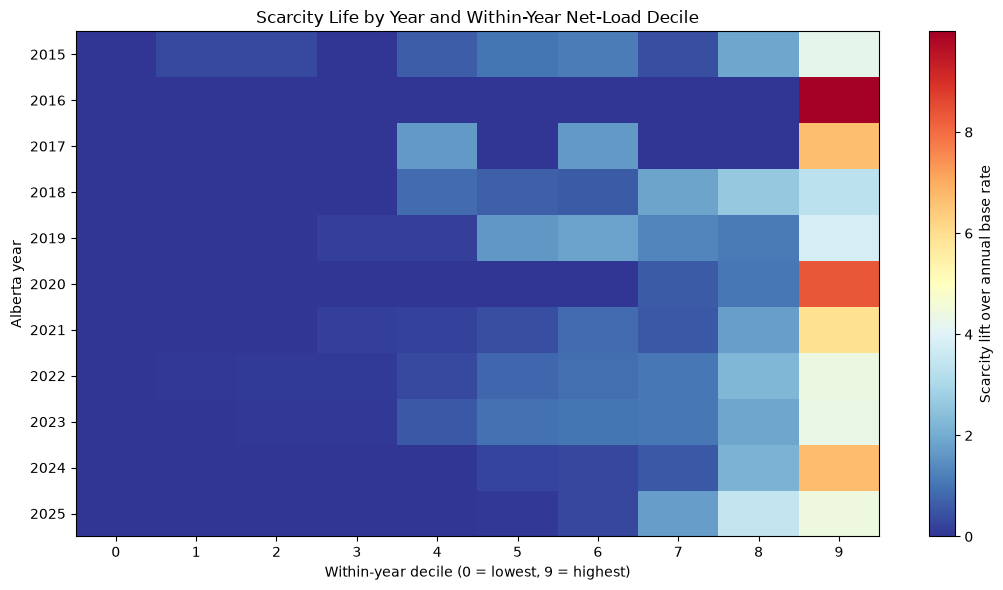

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.0,0.32,0.32,0.00,0.63,1.05,1.16,0.42,1.89,4.21
2016,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.99
2017,0.0,0.00,0.00,0.00,1.67,0.00,1.67,0.00,0.00,6.66
2018,0.0,0.00,0.00,0.00,0.88,0.69,0.59,1.86,2.65,3.33
2019,0.0,0.00,0.00,0.17,0.17,1.64,1.81,1.29,1.12,3.79
2020,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.59,1.08,8.33
2021,0.0,0.00,0.03,0.16,0.23,0.42,0.87,0.55,1.77,5.96
2022,0.0,0.04,0.09,0.11,0.34,0.79,0.94,1.06,2.26,4.37
2023,0.0,0.02,0.05,0.05,0.58,0.97,1.04,1.09,1.88,4.32


In [38]:
# ---------------------------------------------------------------------
# Net-load year-by-decile stability
# ---------------------------------------------------------------------

net_load_year_deciles = build_year_decile_summary(
    scarcity_features['net_load_mw'],
    primary_event,
)

net_load_decile_counts = plot_year_decile_heatmap(
    net_load_year_deciles,
    title = (
        'Scarcity Life by Year and '
        'Within-Year Net-Load Decile' 
    ),
)

net_load_decile_values = (
    net_load_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(net_load_decile_values.round(2))

#### Net-Load Deciles and Annual Scarcity Lift

Scarcity risk is consistently concentrated in the highest within-year net-load deciles. The lowest decile records no scarcity events in any year, while the tenth decile produces the largest scarcity lift throughout the sample. This relationship is especially pronounced in 2024 and 2025, when lift begins rising sharply in the upper three deciles.

The pattern is broadly stable but not perfectly monotonic, particularly in years containing few scarcity events. Large tenth-decile lifts in 2016, 2017, and 2020 should therefore be interpreted cautiously: they show that the limited events were highly concentrated at extreme net load, not necessarily that those years had high absolute scarcity risk. Overall, extreme net load appears to be a persistent indicator of scarcity across different market regimes.

### 3.3 Net load across structural regimes

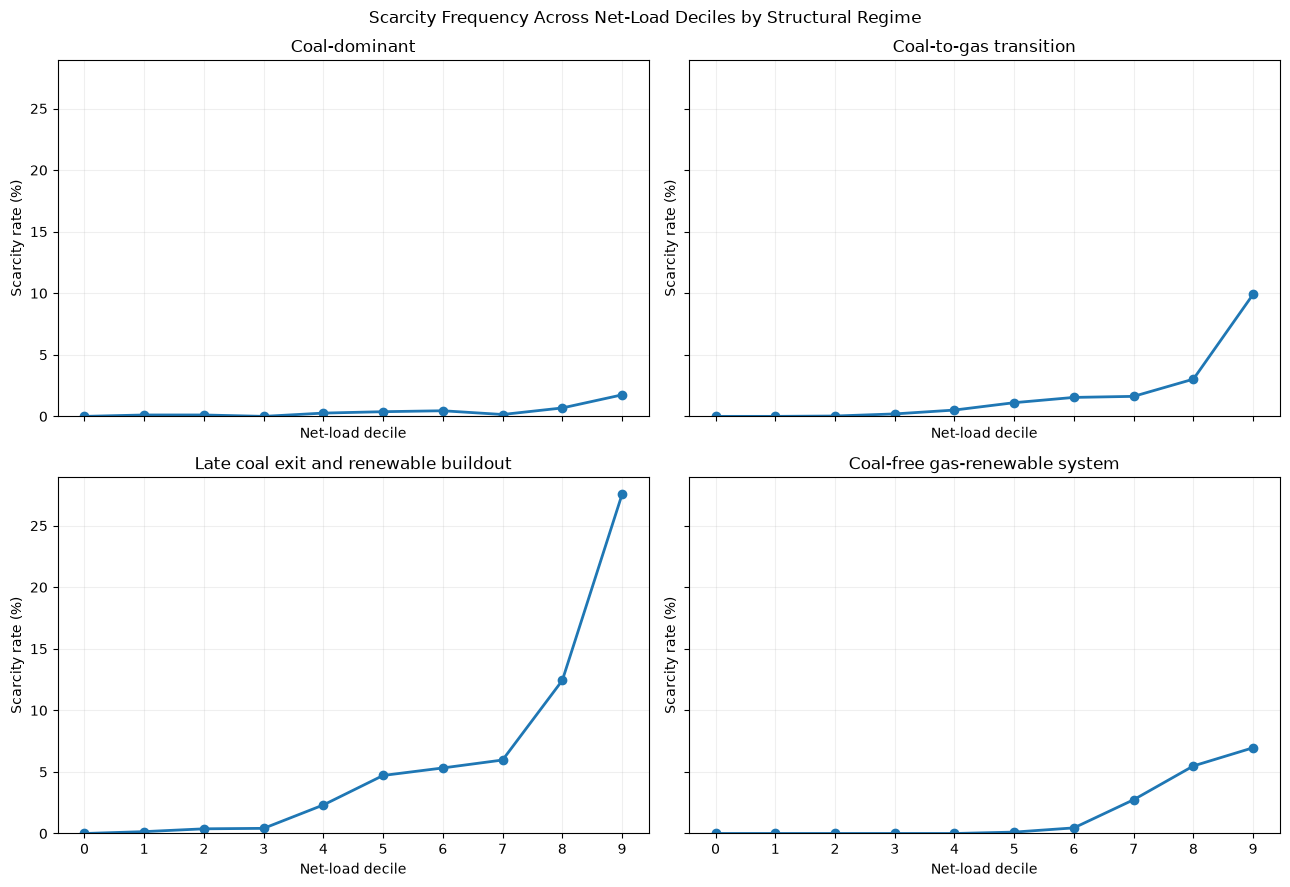

In [39]:
# ---------------------------------------------------------------------
# Compare net-load deciles across structural regimes
# ---------------------------------------------------------------------

net_load_regime_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "net_load_decile":
            scarcity_features["net_load_decile"],
        "scarcity_event": primary_event,
    })
    .dropna()
    .groupby(
        [
            "structural_regime",
            "net_load_decile",
        ],
        observed=True,
    )
    .agg(
        hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True,
    sharey=True,
)

maximum_rate = (
    net_load_regime_summary["scarcity_rate"].max()
    * 100
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = net_load_regime_summary[
        net_load_regime_summary[
            "structural_regime"
        ].eq(regime)
    ]

    axis.plot(
        plot_data["net_load_decile"],
        plot_data["scarcity_rate"] * 100,
        marker="o",
        linewidth=2,
    )

    axis.set_title(regime)
    axis.set_xticks(range(10))
    axis.set_ylim(0, maximum_rate * 1.05)
    axis.set_xlabel("Net-load decile")
    axis.set_ylabel("Scarcity rate (%)")
    axis.grid(alpha=0.20)

fig.suptitle(
    "Scarcity Frequency Across Net-Load Deciles "
    "by Structural Regime"
)

plt.tight_layout()
plt.show()

### 3.4 Net-Load Changes at Scarcity Onset

Net-load changes over one, six, and 24 hours are examined at the onset of each scarcity episode.

This is a descriptive event-onset analysis, not an exhaustive lag-selection exercise. Formal temporal-feature selection belongs in Notebook 5 and the forecasting notebooks.

In [40]:
# ---------------------------------------------------------------------
# Compare net-load changes at scarcity onset
# ---------------------------------------------------------------------

event_onset = (
    primary_event
    & ~primary_event.shift(fill_value=False)
)

net_load_ramp_rows = []

for horizon in [1, 6, 24]:
    net_load_change = (
        scarcity_features["net_load_mw"]
        - scarcity_features["net_load_mw"].shift(
            horizon
        )
    )

    net_load_ramp_rows.append({
        "horizon_hours": horizon,

        "onset_mean_change_mw":
            net_load_change.loc[event_onset].mean(),

        "onset_median_change_mw":
            net_load_change.loc[event_onset].median(),

        "other_hours_mean_change_mw":
            net_load_change.loc[
                ~event_onset
            ].mean(),

        "other_hours_median_change_mw":
            net_load_change.loc[
                ~event_onset
            ].median(),
    })

net_load_onset_ramps = pd.DataFrame(
    net_load_ramp_rows
)

display(net_load_onset_ramps.round(2))

,horizon_hours,onset_mean_change_mw,onset_median_change_mw,other_hours_mean_change_mw,other_hours_median_change_mw
0,1,117.21,105.06,-0.92,-6.34
1,6,629.88,585.11,-4.94,4.80
2,24,426.98,285.78,-3.33,1.08


#### Net-Load Changes at Scarcity Onset

Scarcity onset is preceded by substantial increases in net load. Net load rises by an average of approximately 117 MW over the preceding hour, 630 MW over six hours, and 427 MW over 24 hours. The corresponding median changes are also strongly positive, indicating that the result is not driven solely by a small number of extreme observations.

The largest separation occurs over the six-hour horizon. During other hours, average and median changes remain close to zero across all horizons. This suggests that rapid net-load growth—particularly over several hours—may provide useful advance information about emerging scarcity conditions.

### Demand-Pressure Interpretation

This section should answer three questions:

1. Does net load separate scarcity from normal operation more clearly than gross load?
2. Is the relationship concentrated in the upper tail rather than approximately linear?
3. Does the upper-decile scarcity lift persist across years and structural regimes?

The results describe historical operating conditions. Actual net load is not automatically forecast eligible because an ex-ante model would require forecasts of both demand and renewable generation.

## 4. Supply Availability, Outages, and Interties

### 4.1 Thermal Availability and Headroom

Thermal availability measures the reported coal- and gas-fired supply available during each hour. Thermal headroom measures reported thermal availability minus actual thermal generation.

Thermal headroom is preferable to subtracting total load from thermal availability because Alberta load is also served by hydro, renewable generation, imports, and other resources.

In [41]:
# ---------------------------------------------------------------------
# Compare thermal conditions
# ---------------------------------------------------------------------

thermal_comparison = compare_event_means(
    {
        "Reported thermal availability (MW)":
            scarcity_features[
                "reported_thermal_available_mw"
            ],

        "Reported thermal generation (MW)":
            scarcity_features[
                "reported_thermal_generation_mw"
            ],

        "Thermal headroom (MW)":
            scarcity_features[
                "thermal_headroom_mw"
            ],

        "Thermal utilization (%)":
            scarcity_features[
                "thermal_utilization_pct"
            ],
    },
    primary_event,
)

display(thermal_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported thermal availability (MW),9752.02,9253.68,9728.00,9281.00,-498.34,-5.11
Reported thermal generation (MW),5896.34,6548.21,5891.51,6514.43,651.86,11.06
Thermal headroom (MW),3855.68,2705.48,3777.41,2675.35,-1150.20,-29.83
Thermal utilization (%),60.49,70.74,60.97,70.76,10.25,16.95


In [42]:
# ---------------------------------------------------------------------
# Audit technology-level thermal availability
# ---------------------------------------------------------------------

technology_availability_rows = []

for technology in THERMAL_TECHNOLOGIES: 
    column = f'{technology}_system_available'
    reported = master[column].notna()

    technology_availability_rows.append({
        'technology': technology,
        'coverage_pct': reported.mean() * 100,

        'first_reported': master.loc[
            reported, 
            'timestamp_alberta',
        ].min(),

        'last_reported': master.loc[
            reported,
            'timestamp_alberta',
        ].max(),

        'normal_mean_mw': master.loc[
            reported & ~primary_event, 
            column,
        ].mean(),

        'scarcity_mean_mw': master.loc[
            reported & primary_event,
            column,
        ].mean(),
    })

technology_availability = pd.DataFrame(
    technology_availability_rows
)

technology_availability["difference_mw"] = (
    technology_availability["scarcity_mean_mw"]
    - technology_availability["normal_mean_mw"]
)

technology_availability["pct_difference"] = (
    technology_availability["difference_mw"]
    / technology_availability[
        "normal_mean_mw"
    ].replace(0, np.nan)
    * 100
)

display(technology_availability.round(2))

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_24169/842298059.py:53: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(technology_availability.round(2))


,technology,coverage_pct,first_reported,last_reported,normal_mean_mw,scarcity_mean_mw,difference_mw,pct_difference
0,coal,86.34,2015-01-01 00:00:00-07:00,2024-06-30 23:00:00-06:00,3507.37,1723.32,-1784.05,-50.87
1,cogeneration,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,3093.79,3197.85,104.06,3.36
2,combined_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,1686.78,1678.51,-8.27,-0.49
3,dual_fuel,51.77,2018-03-05 00:00:00-07:00,2024-07-11 23:00:00-06:00,447.83,453.02,5.20,1.16
4,gas_fired_steam,44.67,2021-02-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,2204.66,2168.90,-35.76,-1.62
5,simple_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,753.52,729.55,-23.97,-3.18


#### Thermal Availability and Headroom

Scarcity hours are characterized by a substantially tighter thermal supply position. Reported thermal availability averages approximately 498 MW lower, while thermal generation is about 652 MW higher. Together, these changes reduce average thermal headroom by roughly 1,150 MW, or 29.8%. Thermal utilization consequently rises from 60.5% during normal hours to 70.7% during scarcity—an increase of 10.25 percentage points.

The technology-level availability results require more cautious interpretation because reporting coverage and fleet composition change over time. In particular, coal availability is much lower during scarcity largely because scarcity became more frequent as Alberta’s coal fleet declined. Availability for cogeneration, combined-cycle, dual-fuel, gas-fired steam, and simple-cycle resources differs relatively little between normal and scarcity hours.

Overall, scarcity appears to reflect greater use of a smaller reported thermal availability stack rather than widespread reductions in the availability of every thermal technology. Regime-controlled comparisons are necessary to separate immediate operational tightness from Alberta’s longer-term generation transition.

### 4.2 Absolute and Relative Outage Burden

Absolute outages measure unavailable generation in MW. Relative outage burden divides total outages by reported system capacity. 

The relative measure helps distinguish a large outage in a smaller historical fleet from the same outage magnitude after the fleet expanded. 

In [43]:
# ---------------------------------------------------------------------
# Compare outage conditions
# ---------------------------------------------------------------------

outage_comparison = compare_event_means(
    {
        "Total outages (MW)":
            master["total_outage_mw"],

        "Thermal outages (MW)":
            master["thermal_outage_mw"],

        "Renewable outages (MW)":
            master["renewable_outage_mw"],

        "Simple-cycle outages (MW)":
            master["simple_cycle_outage"],

        "Combined-cycle outages (MW)":
            master["combined_cycle_outage"],

        "Cogeneration outages (MW)":
            master["cogeneration_outage"],

        "Outage share of capacity (%)":
            scarcity_features[
                "outage_share_of_capacity_pct"
            ],
    },
    primary_event,
)

display(
    outage_comparison
    .sort_values(
        'mean_pct_difference',
        ascending = False,
    )
    .round(2)
)

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Renewable outages (MW),465.83,749.97,319.30,628.30,284.14,61.00
Simple-cycle outages (MW),253.74,373.53,211.40,347.40,119.79,47.21
Total outages (MW),3542.30,3883.47,3473.30,3810.40,341.17,9.63
Cogeneration outages (MW),1411.76,1533.68,1378.00,1600.35,121.92,8.64
Outage share of capacity (%),20.79,22.17,20.69,22.06,1.37,6.61
Thermal outages (MW),3072.37,3125.08,3049.10,3095.10,52.71,1.72
Combined-cycle outages (MW),467.52,435.66,284.00,259.00,-31.86,-6.81


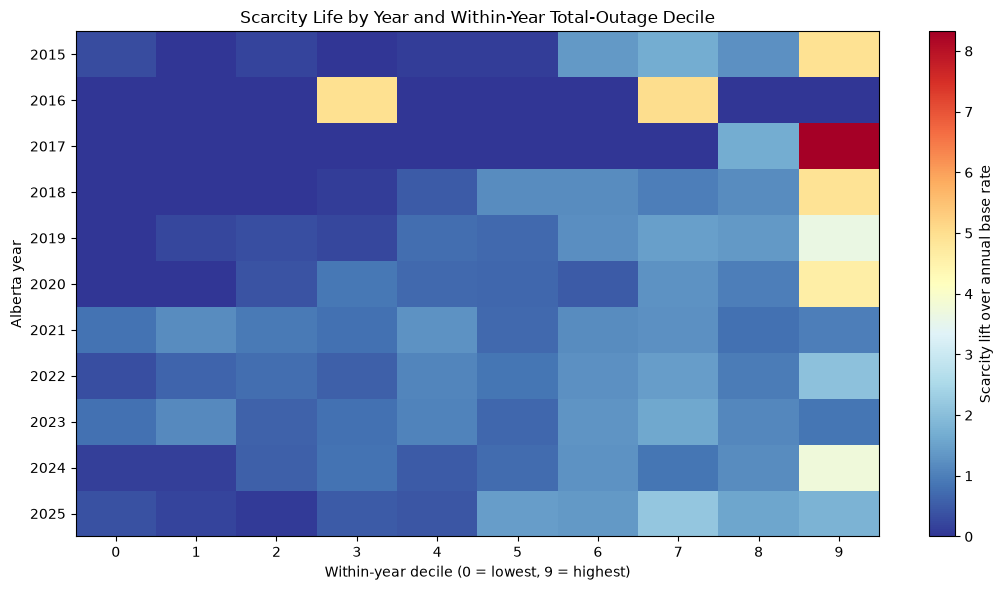

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.32,0.00,0.21,0.00,0.11,0.11,1.37,1.69,1.27,4.94
2016,0.00,0.00,0.00,4.96,0.00,0.00,0.00,5.01,0.00,0.00
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.67,8.32
2018,0.00,0.00,0.00,0.10,0.49,1.18,1.18,0.98,1.17,4.90
2019,0.00,0.26,0.34,0.26,0.78,0.69,1.21,1.47,1.38,3.62
2020,0.00,0.00,0.39,0.88,0.69,0.68,0.49,1.27,0.98,4.60
2021,0.84,1.19,0.94,0.80,1.27,0.71,1.20,1.25,0.81,1.00
2022,0.36,0.62,0.75,0.58,1.08,0.86,1.27,1.45,0.96,2.07
2023,0.79,1.14,0.61,0.81,1.07,0.66,1.32,1.61,1.11,0.87


In [56]:
# ---------------------------------------------------------------------
# Test annual stability of total-outage burden
# ---------------------------------------------------------------------

outage_year_deciles = build_year_decile_summary(
    master['total_outage_mw'],
    primary_event,
)

outage_decile_counts = plot_year_decile_heatmap(
    outage_year_deciles,
    title = (
        'Scarcity Life by Year and '
        'Within-Year Total-Outage Decile'
    ),
)

outage_year_decile_values = (
    outage_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(outage_year_decile_values.round(2))

#### Absolute and Relative Outage Burden

Scarcity hours are associated with higher outage levels, although the relationship varies considerably by technology. Renewable outages show the largest relative difference, averaging 61% more during scarcity, followed by simple-cycle outages at 47%. Total outages increase by approximately 341 MW, or 9.6%, while the outage share of available capacity rises by 1.37 percentage points.

Aggregate thermal outages are only 1.7% higher during scarcity, indicating that the relationship is not explained by uniformly elevated thermal unavailability. Combined-cycle outages are actually lower during scarcity hours, potentially reflecting greater availability or operational commitment from these units when the system is tight. These comparisons are descriptive and may also reflect differences across seasons, generation regimes, and technology-reporting periods.

### 4.3 Imports and Intertie Capability

Observed imports measure the external supply that actually entered Alberta. Available-transfer capability measures the reported ability of the interties to support additional imports.

Actual imports and import capability should not be treated as interchangeable:

- imports may rise in response to domestic scarcity;
- low capability can restrict the amount of external support available; and
- actual flow data may not be known at the intended forecasting origin.

No import-utilization ratio is constructed because the aggregated flow and capability fields require careful alignment before such a ratio can be given a physical interpretation.

In [50]:
# ---------------------------------------------------------------------
# Audit intertie flow and capability coverage
# ---------------------------------------------------------------------

INTERTIE_COLUMNS = [
    "total_imports_mw",
    "total_exports_mw",
    "net_imports_mw",
    "atc_sk_import",
    "atc_wecc_import",
    "ttc_sk_import",
    "ttc_wecc_import",
]

intertie_reporting = pd.DataFrame(
    {
        "missing_hours":
            master[INTERTIE_COLUMNS].isna().sum(),

        "coverage_pct":
            master[INTERTIE_COLUMNS].notna().mean()
            * 100,

        "mean":
            master[INTERTIE_COLUMNS].mean(),

        "minimum":
            master[INTERTIE_COLUMNS].min(),

        "maximum":
            master[INTERTIE_COLUMNS].max(),
    }
)

display(intertie_reporting.round(2))

,missing_hours,coverage_pct,mean,minimum,maximum
total_imports_mw,3666,96.2,262.94,0.0,1154.0
total_exports_mw,3666,96.2,131.52,0.0,1232.0
net_imports_mw,3666,96.2,131.42,-1082.0,1154.0
atc_sk_import,0,100.0,119.36,0.0,153.0
atc_wecc_import,0,100.0,587.50,0.0,1110.0
ttc_sk_import,0,100.0,123.68,0.0,153.0
ttc_wecc_import,0,100.0,1048.79,0.0,1110.0


In [51]:
# ---------------------------------------------------------------------
# Compare intertie conditions
# ---------------------------------------------------------------------

intertie_comparison = compare_event_means(
    {
        "Total imports (MW)":
            master["total_imports_mw"],

        "Total exports (MW)":
            master["total_exports_mw"],

        "Net imports (MW)":
            master["net_imports_mw"],

        "Net imports as share of load (%)":
            scarcity_features[
                "net_import_share_of_load_pct"
            ],

        "Reported import ATC (MW)":
            scarcity_features["import_atc_mw"],

        "Reported import TTC (MW)":
            scarcity_features["import_ttc_mw"],
    },
    primary_event,
)

display(intertie_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Total imports (MW),256.39,515.71,153.0,527.00,259.32,101.14
Total exports (MW),133.74,45.69,0.0,0.00,-88.06,-65.84
Net imports (MW),122.64,470.02,100.0,511.00,347.38,283.24
Net imports as share of load (%),1.30,4.49,1.0,5.03,3.20,246.57
Reported import ATC (MW),709.18,617.28,721.0,657.50,-91.90,-12.96
Reported import TTC (MW),1173.01,1151.48,1263.0,1200.00,-21.53,-1.84


#### Imports and Intertie Capability

Observed intertie flows are available for 96.2% of the study period, while reported Saskatchewan and WECC transfer capabilities have complete coverage. Missing flow observations are retained as missing and are not interpreted as zero imports or exports.

Alberta relies much more heavily on imported electricity during scarcity. Total imports average approximately 516 MW—more than twice their normal-hour level—while exports fall by about 88 MW. Net imports consequently rise from 123 MW during normal hours to 470 MW during scarcity, increasing from 1.3% to 4.5% of Alberta load.

At the same time, reported import ATC averages approximately 92 MW lower during scarcity, a decline of 13%, whereas TTC is only 2% lower. This suggests that scarcity is associated with greater import dependence despite less immediately available transfer capability. The results do not establish whether imports mitigate scarcity, respond to high Alberta prices, or reflect a common tight-system condition; that distinction requires temporal and joint-condition analysis.

### Supply-Side Interpretation

This section should distinguish three mechanisms:

1. low absolute availability;
2. intensive use of otherwise available thermal generation; and
3. externally constrained system support.

Outages should not be classified as unimportant merely because their unconditional relationship is weak. Their effect may become visible only after conditioning on available margin, net load, or intertie capability.

## 5. Available System Margin

### 5.1 Capacity, availability, and system headroom

This is the notebook’s central section.

Four related measures are compared:

- reported capacity margin;
- domestic available margin;
- intertie-supported margin; and
- reported supply headroom.

Reported capacity margin is structural. Domestic available margin reflects contemporaneous reported availability relative to load. Intertie-supported margin adds observed net imports. Reported supply headroom measures available system supply that was not being generated.

None of these measures should be labelled official operating reserve.

In [52]:
# ---------------------------------------------------------------------
# Compare capacity and availability-based margins
# ---------------------------------------------------------------------

margin_comparison = compare_event_means(
    {
        "Reported capacity margin (MW)":
            scarcity_features[
                "reported_capacity_margin_mw"
            ],

        "Domestic available margin (MW)":
            scarcity_features[
                "domestic_available_margin_mw"
            ],

        "Intertie-supported margin (MW)":
            scarcity_features[
                "intertie_supported_margin_mw"
            ],

        "Reported supply headroom (MW)":
            scarcity_features[
                "reported_supply_headroom_mw"
            ],

        "Available margin as share of load (%)":
            scarcity_features[
                "available_margin_pct_of_load"
            ],
    },
    primary_event,
)

display(margin_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported capacity margin (MW),7454.11,7086.33,6671.20,6749.08,-367.78,-4.93
Domestic available margin (MW),3763.77,3083.78,3169.00,2913.00,-679.99,-18.07
Intertie-supported margin (MW),3729.63,3410.65,3295.00,3317.00,-318.98,-8.55
Reported supply headroom (MW),6317.34,6122.93,5743.98,6044.46,-194.41,-3.08
Available margin as share of load (%),39.26,29.77,34.11,27.94,-9.48,-24.16


#### Capacity, availability, and system headroom

### 5.2 Available-Margin Deciles and Annual Stability

Domestic available margin is ranked within each year. Decile 0 contains the tightest 10% of available-margin hours, while decile 9 contains the loosest 10%.

Using within-year deciles prevents structural capacity growth from obscuring the operating relationship.

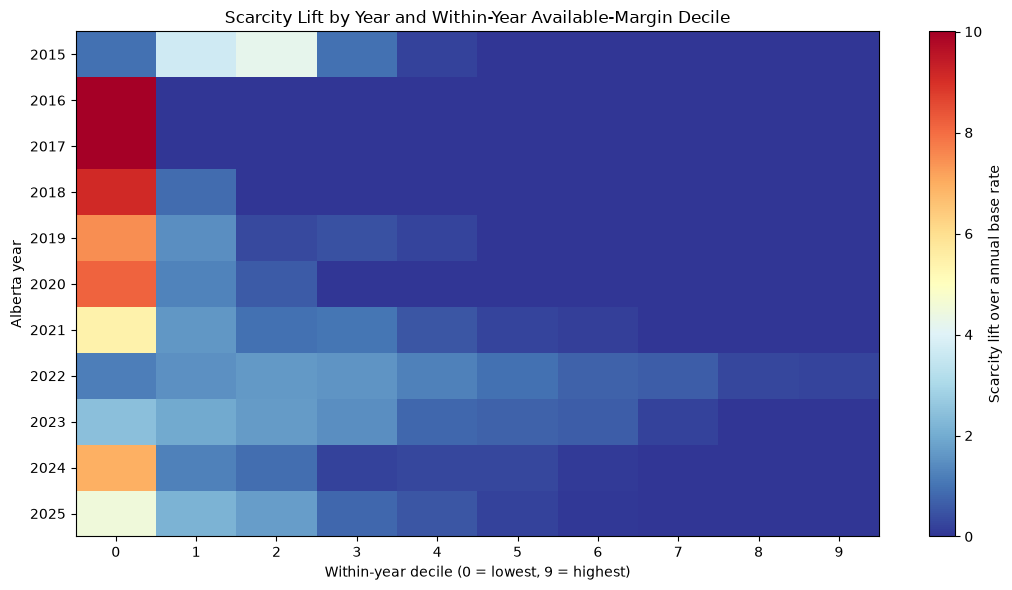

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.95,3.68,4.21,0.95,0.21,0.00,0.00,0.00,0.00,0.00
2016,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018,9.13,0.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2019,7.50,1.47,0.35,0.43,0.26,0.00,0.00,0.00,0.00,0.00
2020,8.13,1.27,0.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2021,5.43,1.61,0.97,1.03,0.52,0.26,0.16,0.03,0.00,0.00
2022,1.18,1.50,1.64,1.58,1.24,0.98,0.73,0.63,0.29,0.24
2023,2.43,1.97,1.71,1.46,0.80,0.71,0.66,0.23,0.02,0.02


In [57]:
# ---------------------------------------------------------------------
# Available-margin year-by-decile stability
# ---------------------------------------------------------------------

available_margin_year_deciles = (
    build_year_decile_summary(
        scarcity_features[
            "domestic_available_margin_mw"
        ],
        primary_event,
    )
)

available_margin_decile_counts = (
    plot_year_decile_heatmap(
        available_margin_year_deciles,
        title=(
            "Scarcity Lift by Year and "
            "Within-Year Available-Margin Decile"
        ),
    )
)

available_margin_year_decile_values = (
    available_margin_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(available_margin_year_decile_values.round(2))